# KIARA — Experiment: Vision Mamba + RAAE

**Diabetic Retinopathy Severity Grading — APTOS 2019**

This notebook trains **Vision Mamba** on the precomputed **RAAE (Retina Anatomy-Aware
Enhancement)** images, using an identical training/evaluation protocol to
`Swin_RAAE.ipynb`, so the two runs are directly comparable:

| | Backbone | Preprocessing |
|---|---|---|
| Experiment 4 | Swin Transformer | RAAE |
| **Experiment 5 (this notebook)** | **Vision Mamba** | **RAAE** |

**This notebook does NOT re-implement RAAE.** It only *consumes* the RAAE PNGs that
`RAAE_Preprocessing.ipynb` already generated (CLAHE / Frangi / vessel enhancement /
optic-disc & macula-aware retina crop all happened upstream, once). If an RAAE image
is missing for a given `id_code`, that sample is skipped with a warning rather than
silently re-processed.

## A note on "Vision Mamba" on Kaggle

True Vision Mamba backbones (Vim, VMamba) depend on the `mamba-ssm` /
`causal-conv1d` CUDA extensions. These require compiling custom CUDA kernels against
the exact torch/CUDA build in the environment, and this compilation **routinely fails
on Kaggle and Colab** (mismatched CUDA toolkit, no nvcc, long build times, silent
wheel-build errors). This is a known, reported problem, not a hypothetical one.

To keep this experiment actually runnable end-to-end on a Kaggle GPU session, this
notebook uses a **two-tier strategy**, resolved automatically in the model cell:

1. **Preferred:** [`MambaVision`](https://github.com/NVlabs/MambaVision) (NVIDIA) loaded
   via `transformers` with `trust_remote_code=True`. MambaVision ships an "eager" PyTorch
   attention/SSM path that does **not** require `mamba-ssm` / `causal-conv1d` to be
   compiled — it just runs slower than the fused CUDA kernels would. This is currently
   the most Kaggle-stable route to a real, pretrained Mamba-family vision backbone.
2. **Fallback:** if MambaVision cannot be installed/downloaded in your session (e.g. no
   internet access enabled on the Kaggle kernel, or the HF download is blocked), the
   notebook falls back to a **from-scratch pure-PyTorch Vision Mamba** (bidirectional
   selective-scan implemented directly in `torch`, no custom CUDA op). It is trained
   from random initialization instead of ImageNet weights. This keeps the pipeline
   runnable, but note it is **not** apples-to-apples with the pretrained Swin baseline —
   flag this explicitly if you use the fallback path for your final reported numbers.

**Action needed from you:** in your Kaggle notebook settings, turn **Internet ON**
and use a **GPU (P100/T4x2)** accelerator before running. If Internet is off, the
notebook auto-detects this and uses the fallback so it doesn't just crash.


In [1]:
# Core
import os
import time
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

# Torch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Vision
import torchvision
from torchvision import transforms
from PIL import Image

# Models
import timm

# Metrics
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    cohen_kappa_score,
    confusion_matrix,
    classification_report,
)

# Plotting
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: Tesla T4


In [2]:
class CFG:
    # ---- Data ----
    IMG_SIZE = 224
    NUM_CLASSES = 5
    BATCH_SIZE = 32
    NUM_WORKERS = 2

    # ---- Training ----
    EPOCHS = 10
    LR = 3e-4
    WEIGHT_DECAY = 1e-4
    LABEL_SMOOTHING = 0.0  # keep identical to Swin+RAAE run; change only if that run used smoothing

    # ---- Backbone selection ----
    # "mambavision" -> nvidia/MambaVision-T-1K via transformers (preferred)
    # "vim_scratch" -> pure-PyTorch bidirectional Vision-Mamba fallback (no pretrained weights)
    MODEL_BACKEND = "auto"       # "auto" | "mambavision" | "vim_scratch"
    MAMBAVISION_HF_ID = "nvidia/MambaVision-T-1K"

    # ---- Paths ----
    RAAE_TRAIN_DIR = "/kaggle/input/datasets/pawanmanghnani/raae-images/RAAE_train_images"
    RAAE_VALID_DIR = "/kaggle/input/datasets/pawanmanghnani/raae-images/RAAE_valid_images"

    # APTOS label CSVs -- adjust the dataset slug if yours differs
    APTOS_TRAIN_CSV = "/kaggle/input/aptos2019-blindness-detection/train.csv"
    # If you don't have a separate official valid.csv (APTOS 2019 ships one labelled train split),
    # this notebook creates a stratified train/valid split from APTOS_TRAIN_CSV by default.
    # Set USE_SEPARATE_VALID_CSV = True and fill APTOS_VALID_CSV if RAAE_valid_images
    # corresponds to a genuinely separate labelled CSV.
    USE_SEPARATE_VALID_CSV = False
    APTOS_VALID_CSV = ""

    VALID_SPLIT = 0.2  # only used when USE_SEPARATE_VALID_CSV is False

    # ---- Output ----
    OUTPUT_DIR = "/kaggle/working"
    BEST_CKPT_PATH = os.path.join(OUTPUT_DIR, "best_mamba_raae.pth")

CFG.OUTPUT_DIR and os.makedirs(CFG.OUTPUT_DIR, exist_ok=True)
print("IMG_SIZE:", CFG.IMG_SIZE, "| BATCH_SIZE:", CFG.BATCH_SIZE, "| EPOCHS:", CFG.EPOCHS)


IMG_SIZE: 224 | BATCH_SIZE: 32 | EPOCHS: 10


In [3]:
def _build_raae_index(raae_dir):
    """Map id_code -> full image path for every PNG/JPG found in raae_dir."""
    raae_dir = Path(raae_dir)
    index = {}
    if not raae_dir.exists():
        print(f"[WARN] RAAE directory does not exist: {raae_dir}")
        return index
    for p in raae_dir.iterdir():
        if p.suffix.lower() in (".png", ".jpg", ".jpeg"):
            index[p.stem] = str(p)
    return index


class RAAEDataset(Dataset):
    """Loads precomputed RAAE-enhanced retinal images + APTOS labels.

    No preprocessing happens here -- images are assumed enhancement-complete.
    """

    def __init__(self, df, raae_dir, transform=None, id_col="id_code", label_col="diagnosis"):
        self.transform = transform
        self.id_col = id_col
        self.label_col = label_col

        raae_index = _build_raae_index(raae_dir)
        records = []
        missing = 0
        for _, row in df.iterrows():
            img_id = str(row[id_col])
            path = raae_index.get(img_id)
            if path is None:
                missing += 1
                continue
            records.append((path, int(row[label_col])))

        if missing:
            print(f"[INFO] {missing} id_code(s) had no matching RAAE image in "
                  f"{raae_dir} and were dropped from this split.")

        self.samples = records
        print(f"[INFO] RAAEDataset ready: {len(self.samples)} samples from {raae_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label


In [4]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()

print("GPU memory cleared")

GPU memory cleared


In [5]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

valid_transform = transforms.Compose([
    transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


In [6]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    if files:
        print("\nPATH:", root)
        print("FILES:", files[:10])


PATH: /kaggle/input/datasets/mariaherrerot/aptos2019
FILES: ['valid.csv', 'test.csv', 'train_1.csv']

PATH: /kaggle/input/datasets/mariaherrerot/aptos2019/val_images/val_images
FILES: ['17f6c7072f61.png', '0243404e8a00.png', '0083ee8054ee.png', '0ac436400db4.png', '0d0a21fd354f.png', '02da652c74b8.png', '15e96e848b46.png', '059bc89df7f4.png', '04d029cfb612.png', '08752092140d.png']

PATH: /kaggle/input/datasets/mariaherrerot/aptos2019/train_images/train_images
FILES: ['6dcde47060f9.png', 'b49b2fac2514.png', 'af6166d57f13.png', '8d13c46e7d75.png', 'c3b15bf9b4bc.png', 'be68322c7223.png', '88e4399d207c.png', '77ab222bf85c.png', '4a05f81b3aba.png', '61d9c88a3a4b.png']

PATH: /kaggle/input/datasets/mariaherrerot/aptos2019/test_images/test_images
FILES: ['ef476be214d4.png', 'ec363f48867b.png', 'f481f76a6b75.png', 'fa7fa797c650.png', 'e7578d8dba72.png', 'eda29a9d78f3.png', 'fe0e2dee1834.png', 'e933923aab15.png', 'ef99c499d665.png', 'fc8fce67fbf8.png']

PATH: /kaggle/input/datasets/pawanmangh

In [7]:
# ============================================================
# APTOS + RAAE Paths
# ============================================================

APTOS_DIR = "/kaggle/input/datasets/mariaherrerot/aptos2019"


# CSV files
TRAIN_CSV = os.path.join(
    APTOS_DIR,
    "train_1.csv"
)

VALID_CSV = os.path.join(
    APTOS_DIR,
    "valid.csv"
)


# RAAE enhanced images
RAAE_TRAIN_DIR = "/kaggle/input/datasets/pawanmanghnani/RAAE_Images/RAAE_train_images"

RAAE_VALID_DIR = "/kaggle/input/datasets/pawanmanghnani/RAAE_Images/RAAE_valid_images"


print("Train CSV:", os.path.exists(TRAIN_CSV))
print("Valid CSV:", os.path.exists(VALID_CSV))

print("RAAE train:", os.path.exists(RAAE_TRAIN_DIR))
print("RAAE valid:", os.path.exists(RAAE_VALID_DIR))

Train CSV: True
Valid CSV: True
RAAE train: False
RAAE valid: False


In [8]:
train_df = pd.read_csv(TRAIN_CSV)
valid_df = pd.read_csv(VALID_CSV)

print(train_df.head())
print(valid_df.head())

print("Train:", len(train_df))
print("Valid:", len(valid_df))

        id_code  diagnosis
0  1ae8c165fd53          2
1  1b329a127307          1
2  1b32e1d775ea          4
3  1b3647865779          0
4  1b398c0494d1          0
        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0
Train: 2930
Valid: 366


In [9]:
# Sanity-check what timm actually has under the "mamba" name right now.
mamba_like_timm_models = timm.list_models("*mamba*")
print("timm models matching '*mamba*':", mamba_like_timm_models)
print("\nNote: 'mambaout_*' entries are MambaOut (SSM-free CNN ablation), NOT Vision Mamba.")
print("True Vision Mamba is sourced below via transformers / a from-scratch SSM implementation.")


timm models matching '*mamba*': ['mambaout_base', 'mambaout_base_plus_rw', 'mambaout_base_short_rw', 'mambaout_base_tall_rw', 'mambaout_base_wide_rw', 'mambaout_femto', 'mambaout_kobe', 'mambaout_small', 'mambaout_small_rw', 'mambaout_tiny', 'test_mambaout']

Note: 'mambaout_*' entries are MambaOut (SSM-free CNN ablation), NOT Vision Mamba.
True Vision Mamba is sourced below via transformers / a from-scratch SSM implementation.


In [10]:
# ---- Tier 1: MambaVision via transformers (preferred) ----
def try_load_mambavision(num_classes, hf_id):
    try:
        from transformers import AutoModelForImageClassification
    except ImportError:
        print("[INFO] `transformers` not available.")
        return None
    try:
        model = AutoModelForImageClassification.from_pretrained(
            hf_id,
            trust_remote_code=True,
            num_labels=num_classes,
            ignore_mismatched_sizes=True,
        )
        print(f"[INFO] Loaded MambaVision backbone '{hf_id}' with a {num_classes}-class head.")
        return model
    except Exception as e:
        print(f"[WARN] Could not load MambaVision ({hf_id}): {e}")
        return None


# ---- Tier 2: pure-PyTorch bidirectional Vision Mamba (fallback, from scratch) ----
class SimpleSSM(nn.Module):
    """Minimal selective state-space scan implemented in plain PyTorch (no custom CUDA op).
    This trades speed for portability -- it will run anywhere torch runs, including
    Kaggle sessions with no internet / no nvcc for compiling mamba-ssm.
    """

    def __init__(self, d_model, d_state=16, expand=2):
        super().__init__()
        self.d_model = d_model
        self.d_inner = d_model * expand
        self.d_state = d_state

        self.in_proj = nn.Linear(d_model, self.d_inner * 2)
        self.conv1d = nn.Conv1d(self.d_inner, self.d_inner, kernel_size=3,
                                 padding=1, groups=self.d_inner)
        self.x_proj = nn.Linear(self.d_inner, d_state * 2 + 1)
        self.dt_proj = nn.Linear(1, self.d_inner)

        A = torch.arange(1, d_state + 1, dtype=torch.float32).repeat(self.d_inner, 1)
        self.A_log = nn.Parameter(torch.log(A))
        self.D = nn.Parameter(torch.ones(self.d_inner))
        self.out_proj = nn.Linear(self.d_inner, d_model)
        self.act = nn.SiLU()

    def forward(self, x):
        # x: (B, L, d_model)
        B, L, _ = x.shape
        xz = self.in_proj(x)
        x_in, z = xz.chunk(2, dim=-1)  # each (B, L, d_inner)

        x_conv = self.act(self.conv1d(x_in.transpose(1, 2)).transpose(1, 2))

        x_dbl = self.x_proj(x_conv)  # (B, L, 2*d_state + 1)
        delta, Bp, Cp = torch.split(x_dbl, [1, self.d_state, self.d_state], dim=-1)
        delta = F.softplus(self.dt_proj(delta))  # (B, L, d_inner)

        A = -torch.exp(self.A_log)  # (d_inner, d_state)
        h = torch.zeros(B, self.d_inner, self.d_state, device=x.device, dtype=x.dtype)
        ys = []
        for t in range(L):
            dA = torch.exp(delta[:, t].unsqueeze(-1) * A)          # (B, d_inner, d_state)
            dB = delta[:, t].unsqueeze(-1) * Bp[:, t].unsqueeze(1)  # (B, d_inner, d_state)
            h = h * dA + dB * x_conv[:, t].unsqueeze(-1)
            y = (h * Cp[:, t].unsqueeze(1)).sum(-1)                 # (B, d_inner)
            ys.append(y)
        y = torch.stack(ys, dim=1)  # (B, L, d_inner)
        y = y + x_conv * self.D
        y = y * self.act(z)
        return self.out_proj(y)


class BiMambaBlock(nn.Module):
    """Bidirectional Mamba block, following the Vim (hustvl) design: forward + backward
    selective scans are summed, as used for non-causal vision sequences."""

    def __init__(self, d_model, d_state=16):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.fwd_ssm = SimpleSSM(d_model, d_state=d_state)
        self.bwd_ssm = SimpleSSM(d_model, d_state=d_state)

    def forward(self, x):
        residual = x
        x = self.norm(x)
        fwd = self.fwd_ssm(x)
        bwd = self.bwd_ssm(x.flip(dims=[1])).flip(dims=[1])
        return residual + fwd + bwd


class VisionMambaScratch(nn.Module):
    """Patch-embed + stack of bidirectional Mamba blocks -> classification head.
    Trained from random init (no pretrained weights available for a from-scratch model).
    """

    def __init__(self, img_size=224, patch_size=16, d_model=192, depth=12,
                 d_state=16, num_classes=5, in_chans=3):
        super().__init__()
        self.patch_embed = nn.Conv2d(in_chans, d_model, kernel_size=patch_size, stride=patch_size)
        num_patches = (img_size // patch_size) ** 2
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

        self.blocks = nn.ModuleList([BiMambaBlock(d_model, d_state=d_state) for _ in range(depth)])
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, num_classes)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x).flatten(2).transpose(1, 2)  # (B, N, d_model)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1) + self.pos_embed
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        return self.head(x[:, 0])


In [11]:
def build_mamba_model(cfg):
    backend = cfg.MODEL_BACKEND
    model = None
    used_backend = None

    if backend in ("auto", "mambavision"):
        model = try_load_mambavision(cfg.NUM_CLASSES, cfg.MAMBAVISION_HF_ID)
        if model is not None:
            used_backend = "mambavision"
        elif backend == "mambavision":
            raise RuntimeError(
                "MODEL_BACKEND='mambavision' was forced but loading failed. "
                "Check Kaggle internet access / the HF model id."
            )

    if model is None:
        print("[INFO] Falling back to from-scratch pure-PyTorch Vision Mamba "
              "(no pretrained weights, no CUDA kernel dependency).")
        model = VisionMambaScratch(
            img_size=cfg.IMG_SIZE, num_classes=cfg.NUM_CLASSES,
        )
        used_backend = "vim_scratch"

    return model.to(DEVICE), used_backend


model, MODEL_BACKEND_USED = build_mamba_model(CFG)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Backend in use: {MODEL_BACKEND_USED}")
print(f"Trainable parameters: {n_params:,}")


config.json: 0.00B [00:00, ?B/s]

configuration_mambavision.py:   0%|          | 0.00/625 [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/nvidia/MambaVision-T-1K:
- configuration_mambavision.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_mambavision.py: 0.00B [00:00, ?B/s]

Encountered exception while importing mamba_ssm: No module named 'mamba_ssm'


[WARN] Could not load MambaVision (nvidia/MambaVision-T-1K): This modeling file requires the following packages that were not found in your environment: mamba_ssm. Run `pip install mamba_ssm`
[INFO] Falling back to from-scratch pure-PyTorch Vision Mamba (no pretrained weights, no CUDA kernel dependency).
Backend in use: vim_scratch
Trainable parameters: 6,039,965


In [12]:
def get_logits(model_output):
    """MambaVision (transformers) returns a ModelOutput with `.logits`;
    the from-scratch model returns a raw tensor. Normalize both to a tensor."""
    if hasattr(model_output, "logits"):
        return model_output.logits
    return model_output


criterion = nn.CrossEntropyLoss(label_smoothing=CFG.LABEL_SMOOTHING)
optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.EPOCHS)


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, all_preds, all_labels = 0.0, [], []
    torch.set_grad_enabled(is_train)

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        if is_train:
            optimizer.zero_grad()

        outputs = get_logits(model(images))
        loss = criterion(outputs, labels)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * images.size(0)
        all_preds.append(outputs.argmax(dim=1).detach().cpu())
        all_labels.append(labels.detach().cpu())

    torch.set_grad_enabled(True)
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc, all_preds, all_labels


In [13]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    if "RAAE_train_images" in dirs or "RAAE_valid_images" in dirs:
        print(root)
        print(dirs)

/kaggle/input/datasets/pawanmanghnani/raae-images
['RAAE_valid_images', 'RAAE_train_images']


In [16]:
import os

for root, dirs, files in os.walk("/kaggle/input/datasets/pawanmanghnani/RAAE_Images"):
    print(root)
    print("Folders:", dirs[:5])
    print("Files:", files[:5])
    print("----------------")

In [19]:
RAAE_DIR = "/kaggle/input/datasets/pawanmanghnani/raae-images"

RAAE_TRAIN_DIR = os.path.join(
    RAAE_DIR,
    "RAAE_train_images"
)

RAAE_VALID_DIR = os.path.join(
    RAAE_DIR,
    "RAAE_valid_images"
)

print(RAAE_TRAIN_DIR)
print(RAAE_VALID_DIR)

print(os.listdir(RAAE_TRAIN_DIR)[:5])
print(os.listdir(RAAE_VALID_DIR)[:5])

/kaggle/input/datasets/pawanmanghnani/raae-images/RAAE_train_images
/kaggle/input/datasets/pawanmanghnani/raae-images/RAAE_valid_images
['6dcde47060f9.png', 'b49b2fac2514.png', 'af6166d57f13.png', '8d13c46e7d75.png', 'c3b15bf9b4bc.png']
['17f6c7072f61.png', '0243404e8a00.png', '0083ee8054ee.png', '0ac436400db4.png', '0d0a21fd354f.png']


In [17]:
# ============================================================
# Create Datasets + DataLoaders
# ============================================================

train_df = pd.read_csv(TRAIN_CSV)
valid_df = pd.read_csv(VALID_CSV)

print("Train rows:", len(train_df))
print("Valid rows:", len(valid_df))


train_dataset = RAAEDataset(
    train_df,
    RAAE_TRAIN_DIR,
    transform=train_transform
)

valid_dataset = RAAEDataset(
    valid_df,
    RAAE_VALID_DIR,
    transform=valid_transform
)


train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
    drop_last=True,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)


print("Train batches:", len(train_loader))
print("Valid batches:", len(valid_loader))

/kaggle/input/datasets/pawanmanghnani/raae-images/RAAE_train_images
/kaggle/input/datasets/pawanmanghnani/raae-images/RAAE_valid_images
['6dcde47060f9.png', 'b49b2fac2514.png', 'af6166d57f13.png', '8d13c46e7d75.png', 'c3b15bf9b4bc.png']
['17f6c7072f61.png', '0243404e8a00.png', '0083ee8054ee.png', '0ac436400db4.png', '0d0a21fd354f.png']


In [21]:
train_df = pd.read_csv(TRAIN_CSV)
valid_df = pd.read_csv(VALID_CSV)

train_dataset = RAAEDataset(
    train_df,
    RAAE_TRAIN_DIR,
    transform=train_transform
)

valid_dataset = RAAEDataset(
    valid_df,
    RAAE_VALID_DIR,
    transform=valid_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    drop_last=True,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

print(len(train_loader), len(valid_loader))

[INFO] RAAEDataset ready: 2930 samples from /kaggle/input/datasets/pawanmanghnani/raae-images/RAAE_train_images
[INFO] RAAEDataset ready: 366 samples from /kaggle/input/datasets/pawanmanghnani/raae-images/RAAE_valid_images
732 92


In [23]:
print("DEVICE:", DEVICE)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
else:
    print("CUDA NOT AVAILABLE")

DEVICE: cuda
Tesla T4


In [24]:
print(next(model.parameters()).device)

cuda:0


In [26]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

images = images.to(DEVICE)
labels = labels.to(DEVICE)

print("Moved to GPU")

out = model(images)

print("Forward pass done")
print(out.shape)

torch.Size([4, 3, 224, 224])
torch.Size([4])
Moved to GPU
Forward pass done
torch.Size([4, 5])


In [29]:
import os

print(CFG.BEST_CKPT_PATH)

print("\nFiles in working:")
print(os.listdir("/kaggle/working"))

/kaggle/working/best_mamba_raae.pth

Files in working:
['.virtual_documents']


In [30]:
import time

model.train()

images, labels = next(iter(train_loader))

images = images.to(DEVICE)
labels = labels.to(DEVICE)

print(images.shape)

start = time.time()

out = model(images)

loss = criterion(out, labels)

loss.backward()

print("One batch time:", time.time()-start)

torch.Size([4, 3, 224, 224])
One batch time: 3.642070770263672


In [33]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [34]:
# ============================================================
# Train Vision Mamba + RAAE (Progress Version)
# ============================================================

import time
import torch

history = {
    "train_loss": [],
    "valid_loss": [],
    "train_acc": [],
    "valid_acc": []
}

best_valid_acc = 0.0


print("Device:", next(model.parameters()).device)
print("Train batches:", len(train_loader))
print("Valid batches:", len(valid_loader))


for epoch in range(1, CFG.EPOCHS + 1):

    epoch_start = time.time()

    print("\n" + "="*60)
    print(f"Epoch {epoch}/{CFG.EPOCHS}")
    print("="*60)


    # =========================
    # TRAIN
    # =========================

    model.train()

    train_loss, train_acc, _, _ = run_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )


    print(
        f"\nTrain Complete | "
        f"Loss: {train_loss:.4f} | "
        f"Acc: {train_acc:.4f}"
    )


    # =========================
    # VALIDATION
    # =========================

    model.eval()

    with torch.no_grad():

        valid_loss, valid_acc, valid_preds, valid_labels = run_epoch(
            model,
            valid_loader,
            criterion
        )


    print(
        f"Valid Complete | "
        f"Loss: {valid_loss:.4f} | "
        f"Acc: {valid_acc:.4f}"
    )


    # scheduler
    scheduler.step()


    # history

    history["train_loss"].append(train_loss)
    history["valid_loss"].append(valid_loss)

    history["train_acc"].append(train_acc)
    history["valid_acc"].append(valid_acc)


    # =========================
    # SAVE BEST MODEL
    # =========================

    if valid_acc > best_valid_acc:

        best_valid_acc = valid_acc

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "epoch": epoch,
                "valid_acc": valid_acc,
                "backend": MODEL_BACKEND_USED
            },
            CFG.BEST_CKPT_PATH
        )

        print("🔥 Best checkpoint saved")


    elapsed = (time.time() - epoch_start) / 60

    print(
        f"Epoch completed in {elapsed:.2f} minutes"
    )


    torch.cuda.empty_cache()



print("\n" + "="*60)
print("TRAINING FINISHED")
print("="*60)

print(
    f"Best Validation Accuracy: {best_valid_acc:.4f}"
)

print(
    f"Checkpoint: {CFG.BEST_CKPT_PATH}"
)


Device: cuda:0
Train batches: 183
Valid batches: 23

Epoch 1/10

Train Complete | Loss: 0.9705 | Acc: 0.6441
Valid Complete | Loss: 0.8588 | Acc: 0.6885
🔥 Best checkpoint saved
Epoch completed in 11.43 minutes

Epoch 2/10

Train Complete | Loss: 0.8841 | Acc: 0.6796
Valid Complete | Loss: 0.8416 | Acc: 0.6967
🔥 Best checkpoint saved
Epoch completed in 11.48 minutes

Epoch 3/10

Train Complete | Loss: 0.8582 | Acc: 0.6967
Valid Complete | Loss: 0.8372 | Acc: 0.6694
Epoch completed in 11.52 minutes

Epoch 4/10

Train Complete | Loss: 0.8471 | Acc: 0.7053
Valid Complete | Loss: 0.8049 | Acc: 0.7022
🔥 Best checkpoint saved
Epoch completed in 11.46 minutes

Epoch 5/10

Train Complete | Loss: 0.8294 | Acc: 0.7066
Valid Complete | Loss: 0.7991 | Acc: 0.7022
Epoch completed in 11.49 minutes

Epoch 6/10

Train Complete | Loss: 0.8214 | Acc: 0.7104
Valid Complete | Loss: 0.7943 | Acc: 0.7077
🔥 Best checkpoint saved
Epoch completed in 11.47 minutes

Epoch 7/10

Train Complete | Loss: 0.8130 | Acc

In [35]:
checkpoint = torch.load(CFG.BEST_CKPT_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print(f"Loaded best checkpoint from epoch {checkpoint['epoch']} "
      f"(backend={checkpoint['backend']}, valid_acc={checkpoint['valid_acc']:.4f})")

_, final_acc, final_preds, final_labels = run_epoch(model, valid_loader, criterion)

acc = accuracy_score(final_labels, final_preds)
f1_weighted = f1_score(final_labels, final_preds, average="weighted")
qwk = cohen_kappa_score(final_labels, final_preds, weights="quadratic")
cm = confusion_matrix(final_labels, final_preds)
report = classification_report(final_labels, final_preds, digits=4)

print(f"Accuracy           : {acc:.4f}")
print(f"Weighted F1         : {f1_weighted:.4f}")
print(f"Quadratic Weighted Kappa (QWK): {qwk:.4f}")
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(report)


Loaded best checkpoint from epoch 9 (backend=vim_scratch, valid_acc=0.7186)
Accuracy           : 0.7186
Weighted F1         : 0.6341
Quadratic Weighted Kappa (QWK): 0.7328

Confusion Matrix:
[[168   0   4   0   0]
 [  1   0  39   0   0]
 [  9   0  95   0   0]
 [  0   0  22   0   0]
 [  3   0  25   0   0]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9282    0.9767    0.9518       172
           1     0.0000    0.0000    0.0000        40
           2     0.5135    0.9135    0.6574       104
           3     0.0000    0.0000    0.0000        22
           4     0.0000    0.0000    0.0000        28

    accuracy                         0.7186       366
   macro avg     0.2883    0.3780    0.3219       366
weighted avg     0.5821    0.7186    0.6341       366



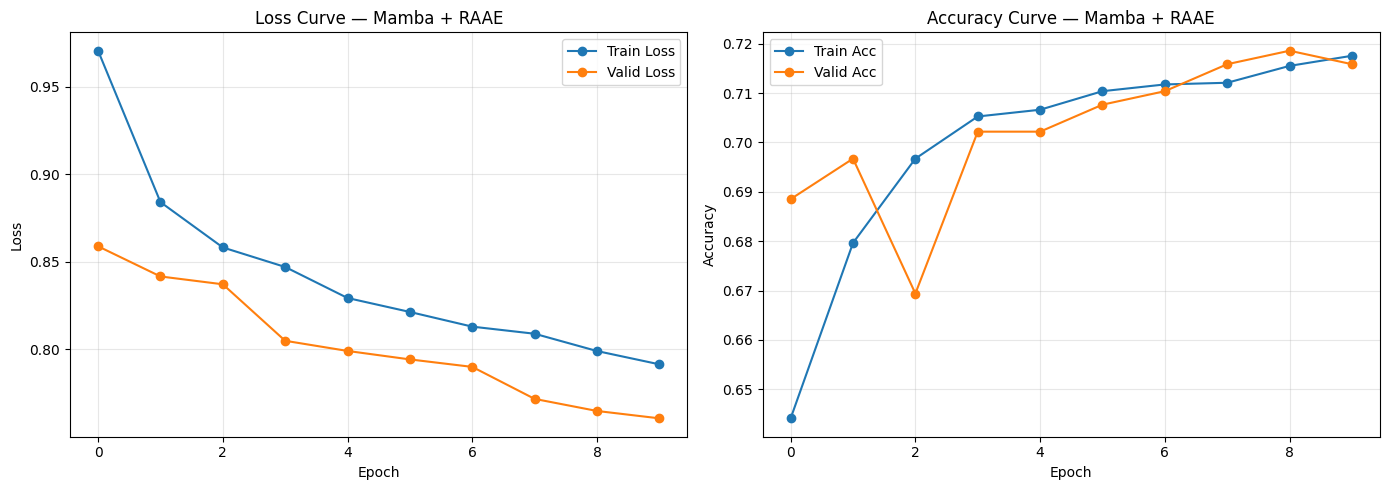

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train Loss", marker="o")
axes[0].plot(history["valid_loss"], label="Valid Loss", marker="o")
axes[0].set_title("Loss Curve — Mamba + RAAE")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history["train_acc"], label="Train Acc", marker="o")
axes[1].plot(history["valid_acc"], label="Valid Acc", marker="o")
axes[1].set_title("Accuracy Curve — Mamba + RAAE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CFG.OUTPUT_DIR, "mamba_raae_training_curves.png"), dpi=150)
plt.show()


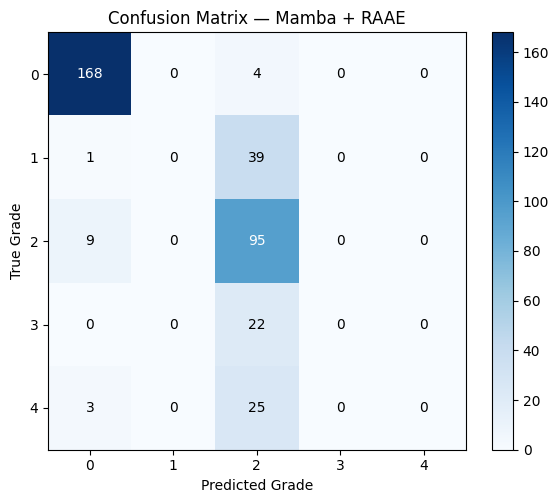

In [37]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Confusion Matrix — Mamba + RAAE")
ax.set_xlabel("Predicted Grade")
ax.set_ylabel("True Grade")
ax.set_xticks(range(CFG.NUM_CLASSES))
ax.set_yticks(range(CFG.NUM_CLASSES))

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(CFG.OUTPUT_DIR, "mamba_raae_confusion_matrix.png"), dpi=150)
plt.show()


In [39]:
DR_GRADE_NAMES = {
    0: "No DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative DR",
}


@torch.no_grad()
def predict_dr_grade(image_path, model=model, transform=valid_transform, device=DEVICE):
    """Run inference on a single RAAE-enhanced retinal image.

    Args:
        image_path: path to an RAAE-enhanced PNG/JPG (NOT a raw fundus image).
    Returns:
        dict with predicted grade (int), grade name (str), and confidence (float).
    """
    model.eval()
    image = Image.open(image_path).convert("RGB")
    x = transform(image).unsqueeze(0).to(device)

    logits = get_logits(model(x))
    probs = F.softmax(logits, dim=1).squeeze(0).cpu().numpy()
    pred_class = int(probs.argmax())

    return {
        "predicted_grade": pred_class,
        "grade_name": DR_GRADE_NAMES.get(pred_class, str(pred_class)),
        "confidence": float(probs[pred_class]),
        "all_class_probs": {DR_GRADE_NAMES[i]: float(p) for i, p in enumerate(probs)},
    }


# Example usage (uncomment and point at a real RAAE-enhanced image path):
# result = predict_dr_grade("/kaggle/input/datasets/pawanmanghnani/raae-images/RAAE_valid_images/<id_code>.png")
# print(result)


## Summary

| Metric | Value |
|---|---|
| Backend used | see `MODEL_BACKEND_USED` above |
| Best epoch | see checkpoint above |
| Best validation accuracy | see Section 8 |
| Weighted F1 | see Section 8 |
| QWK | see Section 8 |

Compare these against the Swin + RAAE run (`best_swin_raae.pth`) using the same
metric set (Accuracy, weighted F1, QWK, confusion matrix) to complete the
Swin-vs-Mamba comparison for the KIARA paper.

**If `MODEL_BACKEND_USED == "vim_scratch"`**: this run used a randomly initialized
backbone, not a pretrained one. Report this explicitly — it is not a fair
apples-to-apples comparison against ImageNet-pretrained Swin unless the Swin
baseline was also trained from scratch. To get a pretrained comparison, re-run
on a Kaggle session with Internet **ON** so `MambaVision` can download.
